In [80]:
! curl -L -o ../models/sam_vit_l_0b3195.pth https://dl.fbaipublicfiles.com/segment_anything/sam_vit_l_0b3195.pth

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 1191M  100 1191M    0     0  9890k      0  0:02:03  0:02:03 --:--:-- 10.5M53M    0     0  10.0M      0  0:01:59  0:00:55  0:01:04  9.8M     0  9770k      0  0:02:04  0:01:18  0:00:46 7700kk      0  0:02:06  0:01:23  0:00:43 7039k0  0:02:05  0:01:39  0:00:26  9.9M 9877k      0  0:02:03  0:02:01  0:00:02 10.4M


In [57]:
import torch
from diffusers import AutoPipelineForText2Image

device = "mps" if torch.backends.mps.is_available() else "cpu"

pipe = AutoPipelineForText2Image.from_pretrained(
    "stabilityai/sdxl-turbo",
    torch_dtype=torch.float16 if device == "mps" else torch.float32,
    variant="fp16" if device == "mps" else None,
)

pipe = pipe.to(device)


def build_sticker_prompt(query: str) -> str:
    return (
        f"A single isolated sticker of {query}. "
        "Exactly one main subject, centered in the image, full body visible. "
        "No other characters, no extra faces, no icons, no repeated objects, "
        "no sticker sheet, no collage, no background elements. "
        "Plain white background, clean outline, simple composition."
    )


def generate_image(query: str):
    prompt = build_sticker_prompt(query)

    image = pipe(
        prompt=prompt,
        negative_prompt=(
            "multiple characters, many objects, sticker sheet, collage, grid, icons, "
            "repeated faces, extra heads, extra people, background scene, decorations, "
            "text, letters, watermark, logo, clutter, cropped body, cut off"
        ),
        num_inference_steps=4,
        guidance_scale=0.0,
    ).images[0]

    return image

/Users/dlifantyev/prsnl/sticker-suggest/.venv/lib/python3.11/site-packages/huggingface_hub/utils/_validators.py:206: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
Loading pipeline components...: 100%|██████████| 7/7 [00:01<00:00,  5.02it/s]


In [81]:
import torch
import numpy as np
import cv2
from PIL import Image, ImageFilter
from segment_anything import sam_model_registry, SamPredictor

sam_checkpoint = "../models/sam_vit_l_0b3195.pth"
model_type = "vit_l"

sam_device = "cpu"

sam = sam_model_registry[model_type](checkpoint=sam_checkpoint)
sam.to(device=sam_device)

sam_predictor = SamPredictor(sam)

In [82]:
def segment_main_object_with_sam(
    image_pil: Image.Image,
    predictor: SamPredictor,
    box_scale: float = 0.9,
) -> np.ndarray:

    image_rgb = image_pil.convert("RGB")
    image_np = np.array(image_rgb)

    predictor.set_image(image_np)

    h, w = image_np.shape[:2]

    box_w = int(w * box_scale)
    box_h = int(h * box_scale)

    x1 = (w - box_w) // 2
    y1 = (h - box_h) // 2
    x2 = x1 + box_w
    y2 = y1 + box_h

    input_box = np.array([x1, y1, x2, y2])

    masks, scores, logits = predictor.predict(
        box=input_box,
        multimask_output=True,
    )

    best_idx = int(np.argmax(scores))
    mask = masks[best_idx].astype(np.uint8)

    return mask

In [ ]:
def apply_alpha_mask(image_pil: Image.Image, mask: np.ndarray) -> Image.Image:
    image_rgba = image_pil.convert("RGBA")
    image_np = np.array(image_rgba)

    alpha = (mask * 255).astype(np.uint8)

    # smooth alpha edges slightly
    alpha = cv2.GaussianBlur(alpha, (5, 5), 0)

    image_np[..., 3] = alpha

    return Image.fromarray(image_np)

In [ ]:
def add_white_outline(
    rgba_image: Image.Image,
    outline_size: int = 10,
) -> Image.Image:
    rgba_image = rgba_image.convert("RGBA")

    alpha = rgba_image.getchannel("A")

    expanded_alpha = alpha.filter(
        ImageFilter.MaxFilter(outline_size * 2 + 1)
    )

    outline = Image.new("RGBA", rgba_image.size, (255, 255, 255, 0))
    outline.putalpha(expanded_alpha)

    return Image.alpha_composite(outline, rgba_image)

In [98]:
def postprocess_with_sam(
    image_pil: Image.Image,
    predictor: SamPredictor,
    outline_size: int = 3,
) -> Image.Image:

    mask = segment_main_object_with_sam(image_pil, predictor)

    sticker_rgba = apply_alpha_mask(image_pil, mask)

    sticker_final = add_white_outline(
        sticker_rgba,
        outline_size=outline_size,
    )

    return sticker_final

100%|██████████| 4/4 [00:01<00:00,  2.36it/s]


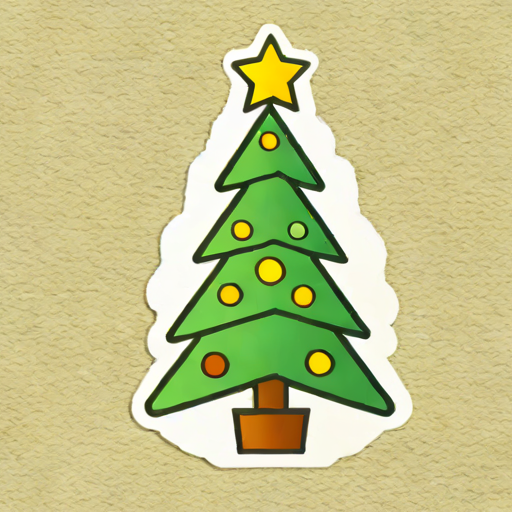

In [94]:
img = generate_image("single Christmas tree sticker")
img

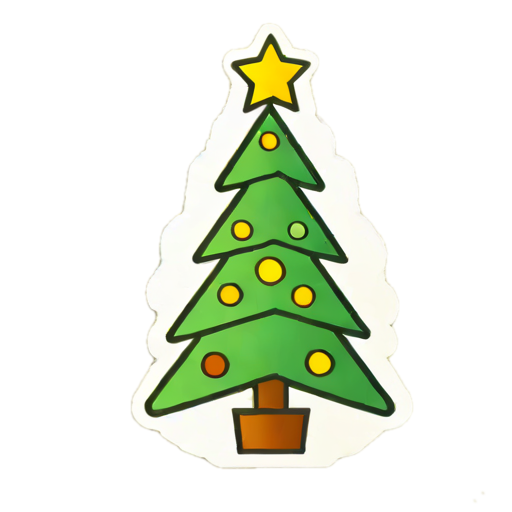

In [95]:
sticker = postprocess_with_sam(
    img,
    sam_predictor,
)
sticker

100%|██████████| 4/4 [00:01<00:00,  2.29it/s]


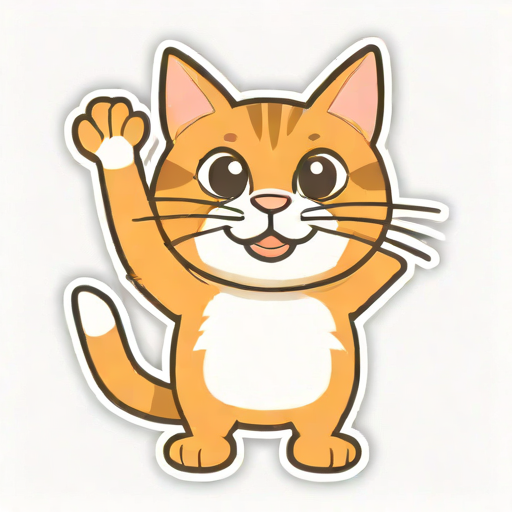

In [96]:
img = generate_image("cat waving sticker")
img

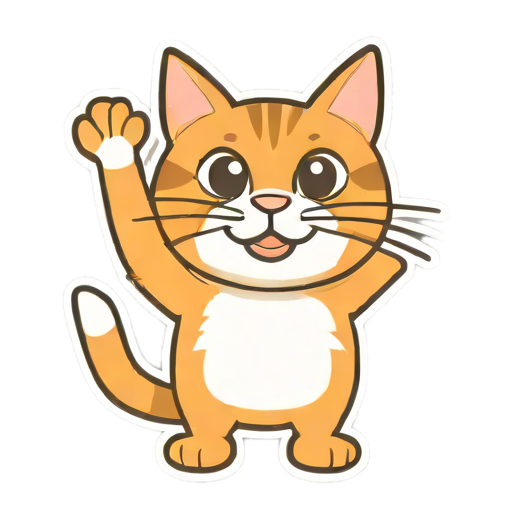

In [99]:
sticker = postprocess_with_sam(
    img,
    sam_predictor,
)
sticker